# L3-D - Linear Quantization II: Per Group Quantization

In this lesson, you will continue to learn about different granularities of performing linear quantization. You will cover `per group` in this notebook.

In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch


def quantization_error(tensor, dequantized_tensor):
    return (dequantized_tensor - tensor).abs().square().mean()


def linear_q_with_scale_and_zero_point(r_tensor, scale, zero_point, dtype=torch.int8):
    """
    Performs simple linear quantization given
    the scale and zero-point.
    """

    # scale tensor and add the zero point
    scaled_and_shifted_tensor = r_tensor / scale + zero_point

    # round the tensor
    rounded_tensor = torch.round(scaled_and_shifted_tensor)

    # we need to clamp to the min/max value of the specified dtype
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    q_tensor = rounded_tensor.clamp(q_min, q_max).to(dtype)
    return q_tensor


def linear_dequantization(quantized_tensor, scale, zero_point):
    """
    Linear de-quantization
    """
    dequantized_tensor = scale * (quantized_tensor.float() - zero_point)

    return dequantized_tensor


def plot_matrix(tensor, ax, title, vmin=0, vmax=1, cmap=None):
    """
    Plot a heatmap of tensors using seaborn
    """
    sns.heatmap(tensor.cpu().numpy(), ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, annot=True, fmt=".2f", cbar=False)
    ax.set_title(title)
    ax.set_yticklabels([])
    ax.set_xticklabels([])


def plot_quantization_errors(original_tensor, quantized_tensor, dequantized_tensor, dtype=torch.int8, n_bits=8):
    """
    A method that plots 4 matrices, the original tensor, the quantized tensor
    the de-quantized tensor and the error tensor.
    """
    # Get a figure of 4 plots
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    # Plot the first matrix
    plot_matrix(original_tensor, axes[0], "Original Tensor", cmap=ListedColormap(["white"]))

    # Get the quantization range and plot the quantized tensor
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    plot_matrix(
        quantized_tensor, axes[1], f"{n_bits}-bit Linear Quantized Tensor", vmin=q_min, vmax=q_max, cmap="coolwarm"
    )

    # Plot the de-quantized tensors
    plot_matrix(dequantized_tensor, axes[2], "Dequantized Tensor", cmap="coolwarm")

    # Get the quantization errors
    q_error_tensor = abs(original_tensor - dequantized_tensor)
    plot_matrix(q_error_tensor, axes[3], "Quantization Error Tensor", cmap=ListedColormap(["white"]))

    fig.tight_layout()
    plt.show()


def get_q_scale_and_zero_point(r_tensor, dtype=torch.int8):
    """
    Get quantization parameters (scale, zero point)
    for a floating point tensor
    """
    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    r_min, r_max = r_tensor.min().item(), r_tensor.max().item()

    scale = (r_max - r_min) / (q_max - q_min)

    zero_point = q_min - (r_min / scale)

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < q_min or zero_point > q_max:
        zero_point = q_min
    else:
        # round and cast to int
        zero_point = int(round(zero_point))
    return scale, zero_point


def linear_quantization(r_tensor, dtype=torch.int8):
    """
    linear quantization
    """

    scale, zero_point = get_q_scale_and_zero_point(r_tensor)

    quantized_tensor = linear_q_with_scale_and_zero_point(r_tensor, scale=scale, zero_point=zero_point, dtype=dtype)

    return quantized_tensor, scale, zero_point


############# From the previous lesson(s) of "Linear Quantization II"
def linear_q_symmetric_per_channel(r_tensor, dim, dtype=torch.int8):

    output_dim = r_tensor.shape[dim]
    # store the scales
    scale = torch.zeros(output_dim)

    for index in range(output_dim):
        sub_tensor = r_tensor.select(dim, index)
        scale[index] = get_q_scale_symmetric(sub_tensor, dtype=dtype)

    # reshape the scale
    scale_shape = [1] * r_tensor.dim()
    scale_shape[dim] = -1
    scale = scale.view(scale_shape)
    quantized_tensor = linear_q_with_scale_and_zero_point(r_tensor, scale=scale, zero_point=0, dtype=dtype)

    return quantized_tensor, scale


def get_q_scale_symmetric(tensor, dtype=torch.int8):
    r_max = tensor.abs().max().item()
    q_max = torch.iinfo(dtype).max

    # return the scale
    return r_max / q_max


###################################

In [2]:
import torch

## Different Granularities for Quantization
- For simplicity, you'll perform these using Symmetric mode.

### Per Group
- For simplicity, you'll quantize a 2D tensor along the rows.

In [3]:
def linear_q_symmetric_per_group(tensor, group_size, dtype=torch.int8):

    t_shape = tensor.shape
    assert t_shape[1] % group_size == 0
    assert tensor.dim() == 2

    tensor = tensor.view(-1, group_size)

    quantized_tensor, scale = linear_q_symmetric_per_channel(tensor, dim=0, dtype=dtype)

    quantized_tensor = quantized_tensor.view(t_shape)

    return quantized_tensor, scale

In [4]:
def linear_dequantization_per_group(quantized_tensor, scale, group_size):
    q_shape = quantized_tensor.shape

    quantized_tensor = quantized_tensor.view(-1, group_size)

    dequantized_tensor = linear_dequantization(quantized_tensor, scale, 0)

    dequantized_tensor = dequantized_tensor.view(q_shape)

    return dequantized_tensor

In [5]:
test_tensor = torch.rand((6, 6))

**Note:** Since the values are random, what you see in the video might be different than what you will get.

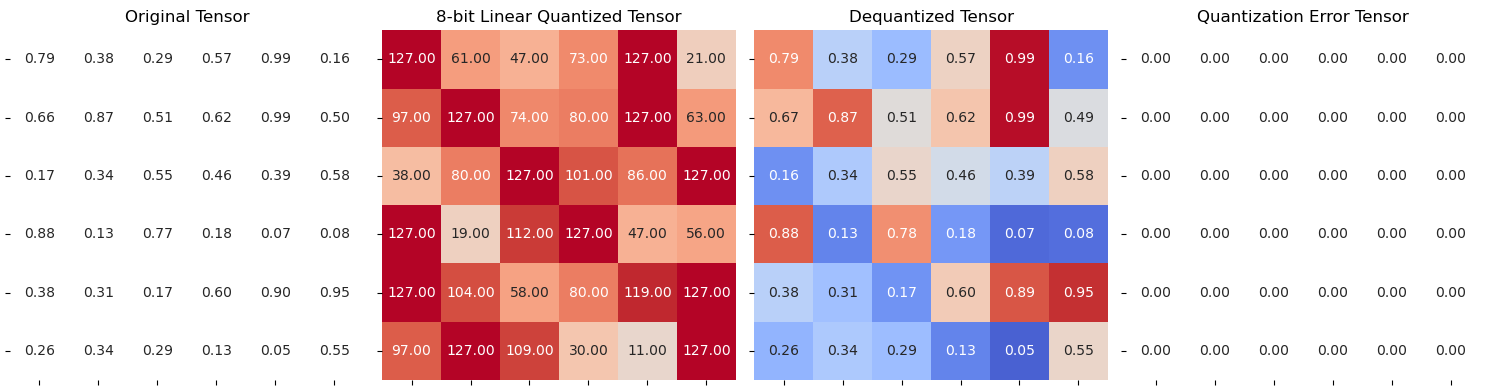

In [6]:
group_size = 3

quantized_tensor, scale = linear_q_symmetric_per_group(test_tensor, group_size=group_size)

dequantized_tensor = linear_dequantization_per_group(quantized_tensor, scale, group_size=group_size)

plot_quantization_errors(test_tensor, quantized_tensor, dequantized_tensor)

In [7]:
print(f"Quantization Error : {quantization_error(test_tensor, dequantized_tensor)}")

Quantization Error : 1.716572455734422e-06
